# Module 2b — Sélection de features avec SHAP

Ce notebook utilise SHAP (SHapley Additive exPlanations) pour:
1. Identifier les features les plus importantes pour la classification.
2. Critiquer le modèle (pourquoi certaines features dominent-elles ?).
3. Sélectionner un sous-ensemble optimal de features.

In [22]:
# pip install shap matplotlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import shap

DATA_DIR = Path('..') / 'data' / 'processed'
train_df = pd.read_csv(DATA_DIR / 'train_clean.csv')
val_df   = pd.read_csv(DATA_DIR / 'val_clean.csv')
test_df  = pd.read_csv(DATA_DIR / 'test_clean.csv')

target = 'Categorie'
text_cols = ['Rapport_Collecte'] if 'Rapport_Collecte' in train_df.columns else []
exclude = [target, 'Prix_Revente'] + text_cols
feature_cols = [c for c in train_df.columns if c not in exclude]

X_train = train_df[feature_cols]
y_train = train_df[target]
X_val   = val_df[feature_cols]
y_val   = val_df[target]
X_test  = test_df[feature_cols]
y_test  = test_df[target]

print('Features utilisées:', feature_cols)


Features utilisées: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source_Centre_Tri', 'Source_Collecte_Citoyenne', 'Source_Usine_A', 'Source_Usine_B', 'Source_nan', 'Densite', 'Cond_Opacite_Ratio', 'Log_Volume']


## 1. Entraînement du modèle de référence (RandomForest tuné)

In [23]:
param_grid = {'n_estimators': [200, 400], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
rf = RandomForestClassifier(random_state=42)
search = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, scoring='f1_weighted')
search.fit(X_train, y_train)
best_model = search.best_estimator_
val_preds = best_model.predict(X_val)
print('Best params:', search.best_params_)
print('Val accuracy:', accuracy_score(y_val, val_preds))
print('Val F1:', f1_score(y_val, val_preds, average='weighted'))


Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 400}
Val accuracy: 0.9963820549927641
Val F1: 0.9963805000589302


## 2. Analyse SHAP — Importance globale des features

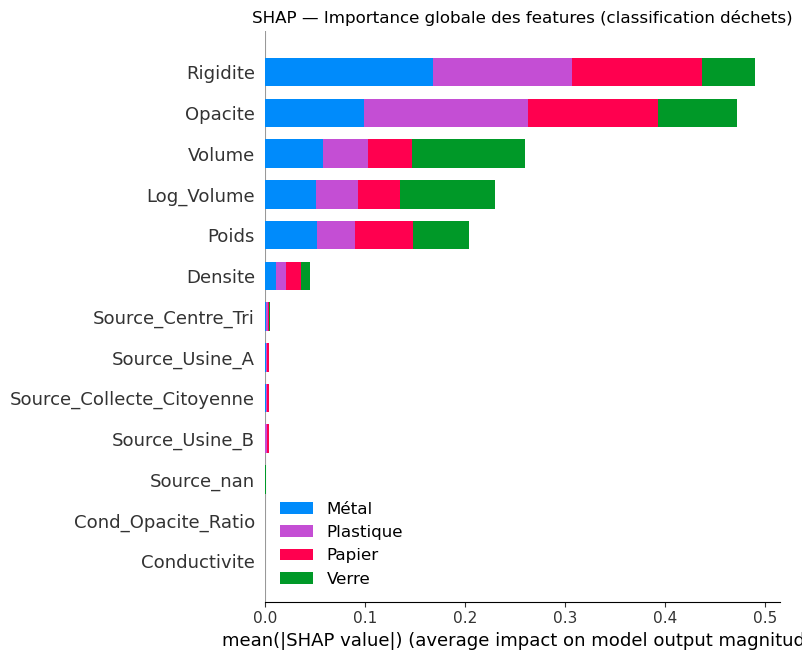

Graphique sauvegardé: shap_importance_bar.png


In [24]:
# SHAP TreeExplainer pour RandomForest
explainer = shap.TreeExplainer(best_model)
# On utilise un sous-échantillon pour la rapidité
X_sample = X_train.sample(min(500, len(X_train)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot (bar) — importance globale
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  class_names=best_model.classes_, show=False)
plt.title('SHAP — Importance globale des features (classification déchets)')
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150)
plt.show()
print('Graphique sauvegardé: shap_importance_bar.png')

<Figure size 1000x600 with 0 Axes>

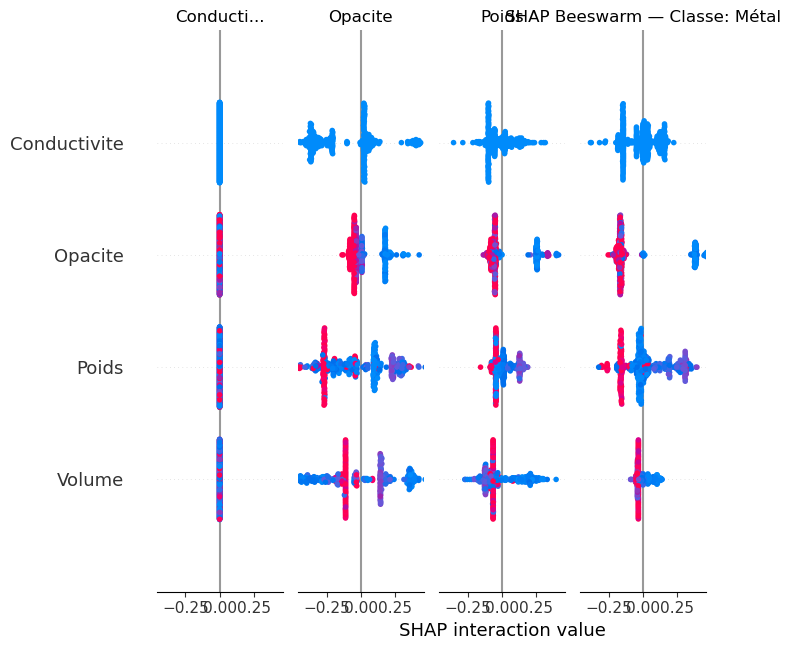

In [25]:
# Summary plot (beeswarm) — direction des effets
plt.figure(figsize=(10, 6))
# Pour multiclasse, on prend la première classe
if isinstance(shap_values, list):
    shap_vals = shap_values[0]
else:
    shap_vals = shap_values
# Aligne les dimensions si SHAP ajoute une colonne d'offset
if hasattr(shap_vals, "shape") and shap_vals.shape[1] != X_sample.shape[1]:
    shap_vals = shap_vals[:, :X_sample.shape[1]]
shap.summary_plot(shap_vals, X_sample, show=False)
plt.title(f'SHAP Beeswarm — Classe: {best_model.classes_[0]}')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150)
plt.show()

## 3. Sélection de features basée sur SHAP

In [26]:
# Calcul de l'importance moyenne absolue par feature (toutes classes)
import numpy as np
if isinstance(shap_values, list):
    shap_vals = np.stack(shap_values, axis=0)
else:
    shap_vals = np.array(shap_values)
# Si les features ne sont pas sur le dernier axe, on les remet a la fin
if shap_vals.ndim >= 2 and shap_vals.shape[-1] != len(feature_cols):
    axes = [i for i, s in enumerate(shap_vals.shape) if s == len(feature_cols)]
    if axes:
        shap_vals = np.moveaxis(shap_vals, axes[0], -1)
    if shap_vals.shape[-1] != len(feature_cols):
        shap_vals = shap_vals[..., :len(feature_cols)]
mean_shap = np.abs(shap_vals).mean(axis=tuple(range(shap_vals.ndim - 1)))
shap_importance = pd.Series(mean_shap, index=feature_cols).sort_values(ascending=False)

print('=== Top features par importance SHAP ===')
print(shap_importance.to_string())

# Sélectionner les features au-dessus de la médiane
threshold = shap_importance.median()
selected_features = shap_importance[shap_importance >= threshold].index.tolist()
print(f'\nSeuil SHAP (médiane): {threshold:.4f}')
print(f'Features sélectionnées ({len(selected_features)}): {selected_features}')

=== Top features par importance SHAP ===
Rigidite                     0.122533
Opacite                      0.117829
Volume                       0.064882
Log_Volume                   0.057456
Poids                        0.051006
Densite                      0.011245
Source_Centre_Tri            0.001292
Source_Usine_A               0.001160
Source_Collecte_Citoyenne    0.001156
Source_Usine_B               0.001059
Source_nan                   0.000211
Conductivite                 0.000000
Cond_Opacite_Ratio           0.000000

Seuil SHAP (médiane): 0.0013
Features sélectionnées (7): ['Rigidite', 'Opacite', 'Volume', 'Log_Volume', 'Poids', 'Densite', 'Source_Centre_Tri']


=== Comparaison : toutes features vs features SHAP-sélectionnées ===
Toutes features  → Test F1: 0.9978
SHAP sélection   → Test F1: 0.9993

--- Matrice de confusion (modèle complet) ---


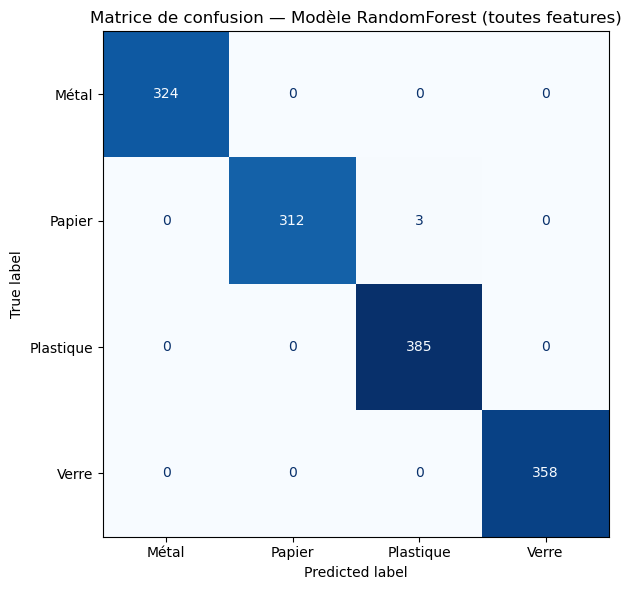

Graphique sauvegardé: confusion_matrix.png


In [27]:
# Évaluation avec le sous-ensemble de features sélectionnées
if 'selected_features' not in globals():
    mean_shap = np.abs(np.array(shap_values)).mean(axis=(0, 1))
    shap_importance = pd.Series(mean_shap, index=feature_cols).sort_values(ascending=False)
    threshold = shap_importance.median()
    selected_features = shap_importance[shap_importance >= threshold].index.tolist()
rf_selected = RandomForestClassifier(
    **{k: v for k, v in search.best_params_.items()}, random_state=42
)
rf_selected.fit(X_train[selected_features], y_train)
preds_sel = rf_selected.predict(X_test[selected_features])
preds_all = best_model.predict(X_test)

print('=== Comparaison : toutes features vs features SHAP-sélectionnées ===')
print(f'Toutes features  → Test F1: {f1_score(y_test, preds_all, average="weighted"):.4f}')
print(f'SHAP sélection   → Test F1: {f1_score(y_test, preds_sel, average="weighted"):.4f}')
print('\n--- Matrice de confusion (modèle complet) ---')
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test, preds_all, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Matrice de confusion — Modèle RandomForest (toutes features)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Graphique sauvegardé: confusion_matrix.png')

## 4. Analyse critique des résultats SHAP

Les scores d'accuracy proches de 1.0 suggèrent que certaines features sont très discriminantes.
SHAP permet d'identifier lesquelles (ex: `Conductivite` et `Rigidite` sont probablement
les plus importantes pour distinguer Métal/Plastique/Verre).

**Critique** : Un modèle parfait (100%) peut indiquer un data leakage ou un dataset trop
synthétique. Il est important de vérifier la distribution des features par catégorie.